# Predicting Soccer Player Market Value — Python Notebook

Companion notebook for the 60-minute intro ML class.
Uses the StataCorp FIFA dataset (n = 1,108 players, 2023) and mirrors the
Stata class demo in Python.

## What you'll need

Run this once in a shell to install everything:

```bash
pip install pandas numpy statsmodels matplotlib seaborn h2o jupyter
```

H2O also requires **Java 8+** (usually already installed on Mac/Linux;
Windows users should install Adoptium/Temurin).

## Split scheme

Single 60/20/20 partition with `random_state=19`:

- **Train** (~665): fits the model
- **Valid** (~222): tunes hyperparameters
- **Test** (~222): honest final evaluation — never touched during model building

For Steps 3, 4, 6, and 7b(default GBM), we combine train + valid → 80% for
training. For Steps 7 and 7b(tuned GBM), we use the 3-way split. All models
are evaluated on the same 222-player test set.

In [11]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 19
np.random.seed(SEED)

sns.set_style('whitegrid')
pd.options.display.max_columns = 40
pd.options.display.float_format = '{:,.2f}'.format

---

## Step 1 — The data

The dataset lives at `https://www.stata.com/users/lil/fifa.dta`. `pandas`
reads `.dta` files directly.

In [12]:
import requests
import os

# Define get_example_ds function to download dataset to the current directory
def get_example_ds(stata_url,local_filename):
    try:
        # Download the file
        response = requests.get(stata_url, timeout=10)
        response.raise_for_status()  # Raise error for bad status codes

        # Save locally
        with open(local_filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded dataset to {os.path.abspath(local_filename)}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading dataset: {e}")
    except (ValueError, OSError) as e:
        print(f"Error reading dataset: {e}")

In [13]:
stata_url = "https://www.stata.com/users/lil/fifa.dta"
local_filename = "fifa.dta"
get_example_ds(stata_url,local_filename)
df = pd.read_stata(local_filename)

Downloaded dataset to C:\Users\yuan.yuan\OneDrive - Summit, LLC\Documents\Python\fifa.dta


In [14]:
#df = pd.read_stata("https://www.stata.com/users/lil/fifa.dta")
print(f"Loaded {len(df)} players, {df.shape[1]} columns")
df.head(8)[['name', 'position', 'age', 'nationality', 'average_market_value']]

Loaded 1108 players, 20 columns


,name,position,age,nationality,average_market_value
0,Aaron Ramsdale,Goalkeeper,24,England,"24,333,334.00"
1,Aaron Wan-Bissaka,Defender,24,England,"31,000,000.00"
2,Abdelhamid Sabiri,Midfield,25,Germany,"2,500,000.00"
3,Abdou Diallo,Defender,26,France,"21,666,666.00"
4,Abdoulaye Bamba,Defender,32,Ivory Coast,"550,000.00"
5,Abdoulaye Doucouré,Midfield,29,France,"23,500,000.00"
6,Adam Armstrong,Attack,25,England,"16,333,333.00"
7,Adam Forshaw,Midfield,30,England,"2,000,000.00"


### Data dictionary — 12 variables used in modeling

| Variable | Type | Meaning |
|---|---|---|
| `name` | string | Player name (identifier, not a predictor) |
| `average_market_value` | euros | **Target** — estimated transfer value |
| `position` | categorical | Goalkeeper / Defender / Midfielder / Attack |
| `age` | integer | Years old (19–41) |
| `height` | integer | Centimeters (163–202) |
| `nationality` | categorical | Country (~50 nations) |
| `league_rank` | categorical | Club's league tier (1 = top) |
| `average_minutes_played` | float | Average minutes played per match |
| `average_goals_per_game` | float | Average goals scored per match |
| `average_assists_per_game` | float | Average assists per match |
| `total_yellow_cards` | integer | Season total of yellow cards |
| `team_win_ratio` | float | Fraction of team's matches won (0–1) |

In [15]:
# Target distribution
df['average_market_value'].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])

count         1,108.00
mean     12,057,304.00
std      15,634,240.00
min          50,000.00
1%          300,000.00
5%          700,000.00
10%       1,066,666.62
25%       2,400,000.00
50%       6,000,000.00
75%      16,666,667.00
90%      29,000,000.00
95%      43,441,666.20
99%      75,000,000.00
max     160,000,000.00
Name: average_market_value, dtype: float64

**Highly right-skewed** — mean (€12M) is more than double the median (€6M),
long tail up to €160M.

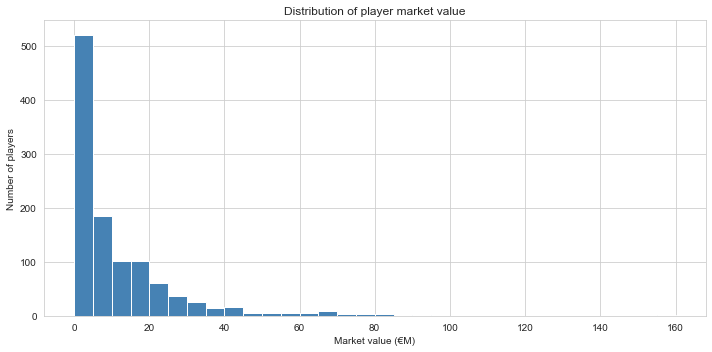

In [16]:
# Histogram of the target
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['average_market_value'] / 1e6, bins=32, color='steelblue', edgecolor='white')
ax.set_xlabel('Market value (€M)')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of player market value')
plt.tight_layout()
plt.show()

---

## Step 2 — Feature exploration

Matrix scatter of five continuous predictors + the target, faceted by
position. Each dot is one player.

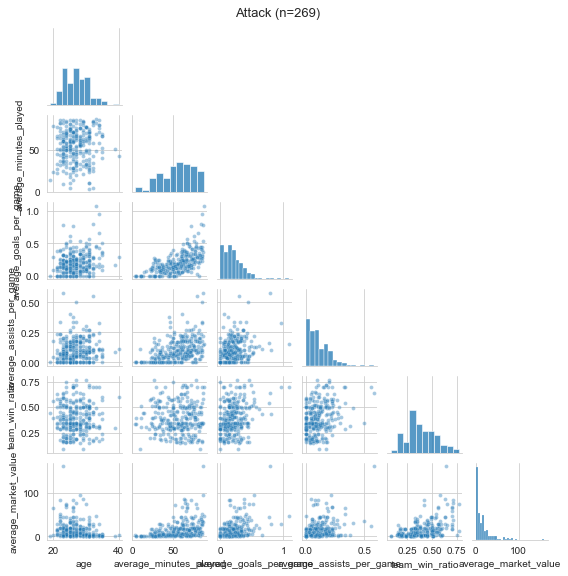

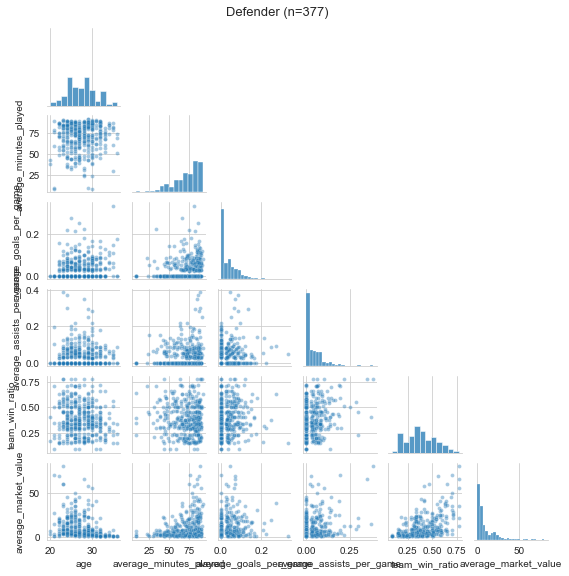

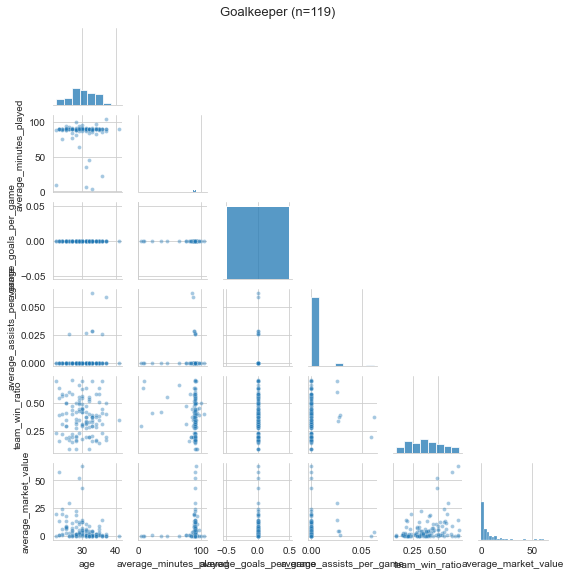

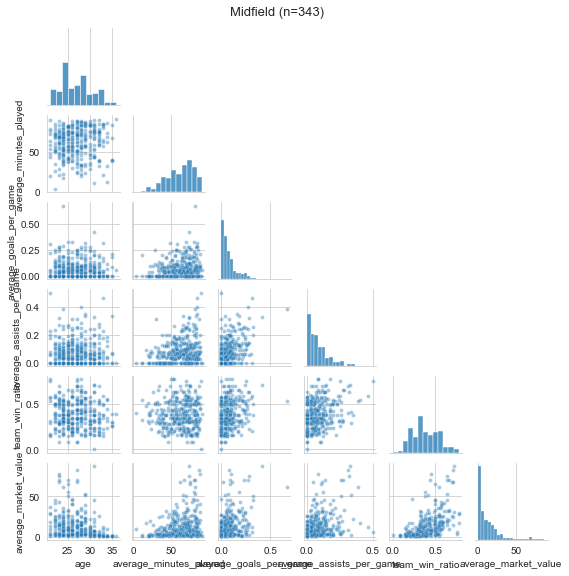

In [17]:
cont_vars = ['age', 'average_minutes_played', 'average_goals_per_game',
             'average_assists_per_game', 'team_win_ratio',
             'average_market_value']

# One scatter matrix per position (4 mini-plots)
for pos in ['Attack', 'Defender', 'Goalkeeper', 'Midfield']:
    sub = df[df['position'] == pos][cont_vars].copy()
    sub['average_market_value'] = sub['average_market_value'] / 1e6
    g = sns.pairplot(sub, corner=True, plot_kws={'alpha': 0.4, 's': 15},
                     height=1.3)
    g.fig.suptitle(f'{pos} (n={len(sub)})', y=1.02, fontsize=13)
    plt.show()

Notice how differently features relate to value across positions:

- **Attackers:** goals + assists per game correlate strongly with value
- **Defenders:** value depends more on age and minutes played than on scoring
- **Goalkeepers:** goals ≈ 0 for everyone; value driven by minutes and team wins
- **Midfielders:** most varied — both scoring and playmaking matter

**Real relationships aren't linear.** OLS will struggle.

---

## Step 3 — OLS baseline

**Predictors** (same 10 for OLS, RF, and GBM):

- `position` — role on the pitch
- `age` — captures career stage; expected inverse-U effect
- `height` — matters for GKs, defenders, target strikers
- `nationality` — brand/premium effects, national-team status
- `league_rank` — playing in a top-tier league boosts visibility
- `average_minutes_played` — proxy for how much the coach trusts you
- `average_goals_per_game` — direct attacking output
- `average_assists_per_game` — direct playmaking output
- `total_yellow_cards` — proxy for playing time and aggressive style
- `team_win_ratio` — teammate quality

In [18]:
# 60/20/20 split
from sklearn.model_selection import train_test_split
train_valid, test = train_test_split(df, test_size=0.20, random_state=SEED)
train, valid = train_test_split(train_valid, test_size=0.25, random_state=SEED)
# 0.25 of 80% = 20% of total
print(f"Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}")
print(f"Train+Valid: {len(train_valid)}")

Train: 664 | Valid: 222 | Test: 222
Train+Valid: 886


In [19]:
# Fit OLS on train + valid combined (886 obs) using statsmodels formula API
formula = ('average_market_value ~ C(position) + age + height + '
           'C(league_rank) + C(nationality) + average_minutes_played + '
           'average_goals_per_game + average_assists_per_game + '
           'total_yellow_cards + team_win_ratio')
ols_fit = smf.ols(formula, data=train_valid).fit()
print(f"R² = {ols_fit.rsquared:.4f}   Adj R² = {ols_fit.rsquared_adj:.4f}")
print(f"Root MSE = {np.sqrt(ols_fit.mse_resid):,.0f}")

R² = 0.5330   Adj R² = 0.4853
Root MSE = 11,077,314


In [20]:
# Top 10 predictors by |t-statistic|
coefs = pd.DataFrame({
    'coef': ols_fit.params,
    'se': ols_fit.bse,
    'tstat': ols_fit.tvalues,
})
coefs['abs_t'] = coefs['tstat'].abs()
top10 = coefs.sort_values('abs_t', ascending=False).head(10)
top10[['coef', 'se', 'tstat']].style.format({
    'coef': '{:,.0f}',
    'se': '{:,.0f}',
    'tstat': '{:.2f}',
})

,coef,se,tstat
team_win_ratio,"39,588,373","2,783,361",14.22
age,"-1,092,707","111,176",-9.83
C(league_rank)[T.5],"-9,386,775","1,527,893",-6.14
average_goals_per_game,"26,807,836","4,372,963",6.13
C(league_rank)[T.2],"-8,519,906","1,489,862",-5.72
average_assists_per_game,"28,847,400","5,752,375",5.01
average_minutes_played,"135,141","27,024",5.00
total_yellow_cards,"641,533","161,822",3.96
C(nationality)[T.Canada],"36,537,434","9,395,735",3.89
C(league_rank)[T.4],"-5,504,829","1,564,542",-3.52


Read the coefficients as dollar effects.  Each year of age subtracts ~€1M;
a one-unit change in `team_win_ratio` adds ~€40M.

Training R² ≈ **0.55**.

---

## Step 4 — OLS test performance

In [49]:
print(test.loc[test['nationality'].isin(train['nationality'].unique()),:].shape)
print(test.shape)

(222, 20)

In [55]:
test_adj = test.loc[test['nationality'].isin(train['nationality'].unique()),:]
# Adding an other category?
pred_ols = ols_fit.predict(test_adj)

# Count impossible negative predictions
n_neg = (pred_ols < 0).sum()
print(f"Predictions below zero (impossible): {n_neg} out of {len(test)}")

Predictions below zero (impossible): 36 out of 222


**Three metrics we'll use throughout:**

- **RMSE** (root mean squared error): typical prediction error in euros.
  Big misses penalized quadratically.
- **MAE** (mean absolute error): average absolute miss. More robust to outliers.
- **R²**: fraction of test-set variance explained. 0 = same as predicting the mean;
  1 = perfect.

In [56]:
def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    rmse = np.sqrt(np.mean(err ** 2))
    mae = np.abs(err).mean()
    r2 = 1 - np.sum(err ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

metrics_ols = regression_metrics(test_adj['average_market_value'].values,
                                  pred_ols.values)
for k, v in metrics_ols.items():
    if k == 'R²':
        print(f"  {k:5s} = {v:.4f}")
    else:
        print(f"  {k:5s} = €{v:,.0f}")

  RMSE  = €10,676,698
  MAE   = €7,344,948
  R²    = 0.5894


In [57]:
# 10 sample players — actual vs. OLS prediction
comparison = test_adj.copy()
comparison['pred_ols'] = pred_ols
comparison['error'] = comparison['average_market_value'] - comparison['pred_ols']

show_cols = ['name', 'position', 'average_market_value', 'pred_ols', 'error']
fmt = {'average_market_value': '{:,.0f}', 'pred_ols': '{:,.0f}',
       'error': '{:,.0f}'}

# Top 3 stars, 4 middle, 3 cheap
stars = comparison.nlargest(3, 'average_market_value')
mid = comparison.iloc[(comparison['average_market_value'] -
                       comparison['average_market_value'].median()).abs()
                      .argsort()][:4]
cheap = comparison.nsmallest(3, 'average_market_value')

print("Stars (top 3):")
display(stars[show_cols].style.format(fmt))
print("\nMid-tier (near median):")
display(mid[show_cols].style.format(fmt))
print("\nCheapest (bottom 3):")
display(cheap[show_cols].style.format(fmt))

Stars (top 3):


,name,position,average_market_value,pred_ols,error
557,Kevin De Bruyne,Midfield,"87,500,000","49,049,608","38,450,392"
1041,Trent Alexander-Arnold,Defender,"80,000,000","46,582,902","33,417,098"
876,Raheem Sterling,Attack,"77,500,000","39,374,295","38,125,705"



Mid-tier (near median):


,name,position,average_market_value,pred_ols,error
783,Mërgim Vojvoda,Midfield,"5,000,000","8,003,913","-3,003,913"
804,Nico Schulz,Defender,"5,000,000","10,241,501","-5,241,501"
828,Oliver Baumann,Goalkeeper,"4,750,000","1,255,323","3,494,677"
655,Mamadou Sakho,Defender,"4,750,000","-1,216,439","5,966,439"



Cheapest (bottom 3):


,name,position,average_market_value,pred_ols,error
942,Samir Ujkani,Goalkeeper,"200,000","-2,759,050","2,959,050"
392,Ibrahima Baldé,Attack,"233,333","10,732,432","-10,499,099"
719,Matthieu Dreyer,Goalkeeper,"300,000","-6,349,731","6,649,731"


**Two failure patterns visible:**

1. **Stars systematically under-predicted** by €30–50M — OLS can't reach the
   extreme high end.
2. **Cheap players get negative predictions** — OLS extrapolates linearly past zero.

---

## Step 5 — Random forest concept

RF grows many decision trees.  Each tree:
- sees a random 63% bootstrap sample of training rows
- at each split, considers a random subset of predictors

The forest averages the trees' predictions.  Two things OLS can't do:

1. **Nonlinear splits** — the model discovers thresholds (e.g., "age > 30")
   automatically.
2. **No distributional assumptions** — the target can be as skewed as it wants.

*Question for the class:* which do you think matters more here?

---

## Step 6 — Default RF with 5-fold cross-validation

We use the H2O Python API (same engine as the Stata `h2oml` command).  Requires
Java installed.

In [31]:
#!pip install h2o

H2O requires Java, https://docs.h2o.ai/h2o/latest-stable/h2o-docs/welcome.html#java-requirements

Download and install most recent Java, https://www.oracle.com/java/technologies/downloads/#jdk26-windows

In [59]:
import h2o
from h2o.estimators import H2ORandomForestEstimator, H2OGradientBoostingEstimator
from h2o.grid.grid_search import H2OGridSearch

# Start the local H2O cluster (first call takes ~30 seconds)
h2o.init()

# Convert pandas DataFrames to H2O frames
train_valid_h2o = h2o.H2OFrame(train_valid)
train_h2o = h2o.H2OFrame(train)
valid_h2o = h2o.H2OFrame(valid)
test_h2o = h2o.H2OFrame(test)

# Ensure categorical columns are typed as factors ("enums" in H2O)
for c in ['position', 'nationality', 'league_rank']:
    for frame in [train_valid_h2o, train_h2o, valid_h2o, test_h2o]:
        frame[c] = frame[c].asfactor()

predictors = ['position', 'age', 'height', 'nationality', 'league_rank',
              'average_minutes_played', 'average_goals_per_game',
              'average_assists_per_game', 'total_yellow_cards',
              'team_win_ratio']
target = 'average_market_value'

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 26.0.2+10-55, mixed mode, sharing)
  Starting server from C:\Users\yuan.yuan\Anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\YUAN~1.YUA\AppData\Local\Temp\tmpzbdtv3qh
  JVM stdout: C:\Users\YUAN~1.YUA\AppData\Local\Temp\tmpzbdtv3qh\h2o_yuan_yuan_started_from_python.out
  JVM stderr: C:\Users\YUAN~1.YUA\AppData\Local\Temp\tmpzbdtv3qh\h2o_yuan_yuan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_yuan_yuan_90cyj1
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.917 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


**Cross-validation** rotates through 5 different train/hold-out splits within
the training data.  Gives a stable performance estimate without needing a
separate held-out set.

In [32]:
# Default RF with 5-fold CV
rf_default = H2ORandomForestEstimator(
    ntrees=50,
    nfolds=5,
    seed=SEED,
    model_id='rf_default',
)
rf_default.train(x=predictors, y=target, training_frame=train_valid_h2o)

# Report training, CV, and test metrics
def print_metrics(model, test_frame, label='Model'):
    perf_train = model.model_performance()
    perf_test = model.model_performance(test_frame)
    perf_cv = model.model_performance(xval=True)
    print(f"{label}:")
    print(f"  Training  RMSE = €{perf_train.rmse():>12,.0f}  MAE = €{perf_train.mae():>12,.0f}  R² = {perf_train.r2():.4f}")
    if perf_cv:
        print(f"  CV (5)    RMSE = €{perf_cv.rmse():>12,.0f}  MAE = €{perf_cv.mae():>12,.0f}  R² = {perf_cv.r2():.4f}")
    print(f"  Test      RMSE = €{perf_test.rmse():>12,.0f}  MAE = €{perf_test.mae():>12,.0f}  R² = {perf_test.r2():.4f}")

print_metrics(rf_default, test_h2o, 'Default RF')

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
Default RF:
  Training  RMSE = €  10,783,291  MAE = €   6,337,991  R² = 0.5117
  CV (5)    RMSE = €  11,794,441  MAE = €   6,760,895  R² = 0.4159
  Test      RMSE = €   9,683,225  MAE = €   5,894,001  R² = 0.6500


Training, CV, and test metrics all agree at R² ≈ 0.51–0.53.  Healthy sign — **no overfitting**.

RF vs. OLS: R² 0.530 vs. 0.515 — 1.5 percentage points better.  Also **zero
impossible predictions** (RF's leaf averages are bounded within training data).

---

## Step 7 — Tuned RF via three-way holdout

**What is deviance?**  For Gaussian regression, deviance = MSE.  Lower is
better.  Grid search fits an RF at each candidate `ntrees` value, then computes
deviance on the validation set.  The `ntrees` value with the lowest validation
deviance wins.

**Alternatives to deviance:**
- **RMSE** — square root of MSE. Same ordering, easier to interpret.
- **MAE** — robust to outliers. Different ordering.
- **R²** — normalized, unit-free.
- **AIC/BIC** — for likelihood-based models; penalize complexity.
- **AUC / log-loss** — for classification.

Deviance is the default because it's differentiable, well-behaved, and matches
what the model is minimizing internally.

In [33]:
# Grid search: tune ntrees on the validation set
hyper = {'ntrees': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]}

rf_grid = H2OGridSearch(
    model=H2ORandomForestEstimator(seed=SEED),
    hyper_params=hyper,
    grid_id='rf_grid',
)
rf_grid.train(x=predictors, y=target,
              training_frame=train_h2o,
              validation_frame=valid_h2o)

# Show grid, sorted by validation deviance (lower = better)
sorted_grid = rf_grid.get_grid(sort_by='mse', decreasing=False)
print(sorted_grid)

drf Grid Build progress: |███████████████████████████████████████████████████████| (done) 100%
Hyper-Parameter Search Summary: ordered by increasing mse
    ntrees    model_ids         mse
--  --------  ----------------  -----------
    50        rf_grid_model_1   1.11407e+14
    150       rf_grid_model_3   1.15415e+14
    450       rf_grid_model_9   1.15785e+14
    100       rf_grid_model_2   1.16152e+14
    200       rf_grid_model_4   1.16654e+14
    500       rf_grid_model_10  1.16735e+14
    400       rf_grid_model_8   1.16987e+14
    250       rf_grid_model_5   1.17239e+14
    300       rf_grid_model_6   1.17908e+14
    350       rf_grid_model_7   1.17998e+14


In [34]:
# Take the winner, predict on test
rf_tuned = sorted_grid.models[0]
print_metrics(rf_tuned, test_h2o, 'Tuned RF')

Tuned RF:
  Training  RMSE = €  11,364,889  MAE = €   6,812,578  R² = 0.4640
  Test      RMSE = €  10,221,727  MAE = €   6,211,861  R² = 0.6100


**Tuning hurt slightly.**  Tuning consumes 20% of the data as a validation
set, leaving only ~665 training rows (vs. ~886 for the default RF).  The loss
of training data outweighs the tuning gain.

**Lesson:** tuning isn't free.  Sometimes a simple model on more data beats a
tuned model on less.

---

## Step 7b — Gradient boosting machine

### How GBM works

GBM fits trees **sequentially**, not in parallel like RF.  The idea:

1. Fit tree 1 to predict `y`.  Compute residuals `y − ŷ₁`.
2. Fit tree 2 to predict those residuals.  Add its predictions (scaled) to tree 1's.
3. Fit tree 3 to the *new* residuals.  Add its predictions.
4. Repeat for `ntrees` iterations.

Each tree corrects the previous trees' mistakes.  The **learning rate**
(default 0.1) is a shrinkage factor that multiplies each tree's contribution —
smaller learning rate means each tree contributes less, and you need more trees
to accumulate the same total fit.  A small learning rate with many trees
usually generalizes better than a large learning rate with few trees.

Where RF trees are **independent** and averaged (`ŷ = mean of B trees`), GBM
trees are **cumulative** and summed
(`ŷ = ∑ αₘ · ŷₘ`, where αₘ is the shrunken contribution).

### Default GBM with 5-fold CV

In [35]:
gbm_default = H2OGradientBoostingEstimator(
    ntrees=50,
    learn_rate=0.1,
    nfolds=5,
    seed=SEED,
    model_id='gbm_default',
)
gbm_default.train(x=predictors, y=target, training_frame=train_valid_h2o)
print_metrics(gbm_default, test_h2o, 'Default GBM')

gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
Default GBM:
  Training  RMSE = €   5,989,669  MAE = €   3,444,302  R² = 0.8493
  CV (5)    RMSE = €  11,605,588  MAE = €   6,692,207  R² = 0.4344
  Test      RMSE = €   8,929,498  MAE = €   5,795,470  R² = 0.7024


Notice the huge **training-vs-CV gap in R²** (typically 0.88 → 0.55).  GBM
fits training data very closely — that's a signature of the algorithm's
aggressiveness.  CV and test metrics tell you the honest generalization
performance.

### Tuned GBM: 3-way holdout grid over `learn_rate` × `ntrees`

In [36]:
hyper_gbm = {
    'learn_rate': [0.05, 0.1, 0.2],
    'ntrees': [100, 300, 500],
}
gbm_grid = H2OGridSearch(
    model=H2OGradientBoostingEstimator(seed=SEED),
    hyper_params=hyper_gbm,
    grid_id='gbm_grid',
)
gbm_grid.train(x=predictors, y=target,
               training_frame=train_h2o,
               validation_frame=valid_h2o)

sorted_gbm_grid = gbm_grid.get_grid(sort_by='mse', decreasing=False)
print(sorted_gbm_grid)

gbm Grid Build progress: |███████████████████████████████████████████████████████| (done) 100%
Hyper-Parameter Search Summary: ordered by increasing mse
    learn_rate    ntrees    model_ids         mse
--  ------------  --------  ----------------  -----------
    0.1           100       gbm_grid_model_2  9.21361e+13
    0.05          100       gbm_grid_model_1  9.5484e+13
    0.05          300       gbm_grid_model_4  9.67625e+13
    0.1           300       gbm_grid_model_5  9.99633e+13
    0.2           100       gbm_grid_model_3  1.00816e+14
    0.05          500       gbm_grid_model_7  1.01198e+14
    0.1           500       gbm_grid_model_8  1.03659e+14
    0.2           300       gbm_grid_model_6  1.07052e+14
    0.2           500       gbm_grid_model_9  1.08305e+14


In [37]:
gbm_tuned = sorted_gbm_grid.models[0]
print_metrics(gbm_tuned, test_h2o, 'Tuned GBM')

Tuned GBM:
  Training  RMSE = €   4,750,233  MAE = €   2,741,549  R² = 0.9064
  Test      RMSE = €   9,714,484  MAE = €   6,125,639  R² = 0.6478


**Same pattern as RF: tuning made it worse.**  Losing training data to the
validation split costs more than tuning gains.

### Four-model comparison

Aggregate the test-set metrics from all four models:

In [ ]:
def test_row(model, name):
    perf = model.model_performance(test_h2o)
    return {'Model': name, 'RMSE (€)': perf.rmse(), 'MAE (€)': perf.mae(),
            'R²': perf.r2()}

ols_row = {'Model': 'OLS',
           'RMSE (€)': metrics_ols['RMSE'],
           'MAE (€)': metrics_ols['MAE'],
           'R²': metrics_ols['R²']}
summary = pd.DataFrame([
    ols_row,
    test_row(rf_default, 'RF + cv(5)'),
    test_row(rf_tuned, 'Tuned RF'),
    test_row(gbm_default, 'GBM + cv(5)'),
    test_row(gbm_tuned, 'Tuned GBM'),
])
summary.style.format({'RMSE (€)': '{:,.0f}', 'MAE (€)': '{:,.0f}', 'R²': '{:.4f}'})

**The winner is default GBM.**  All interpretability below uses this model.

---

## Step 8 — Why we need SHAP (motivation)

**Variable importance** answers: "Which features does the model rely on most,
overall?"  It's a *global* answer — one score per feature.

**SHAP** answers: "For THIS specific player, how much does each feature push
the prediction up or down?"  It's a *local* answer — one number per feature per
prediction.

Both matter.  Variable importance tells the marketing team what counts.  SHAP
tells a scout why the model rates Kane at €75M and not €95M.

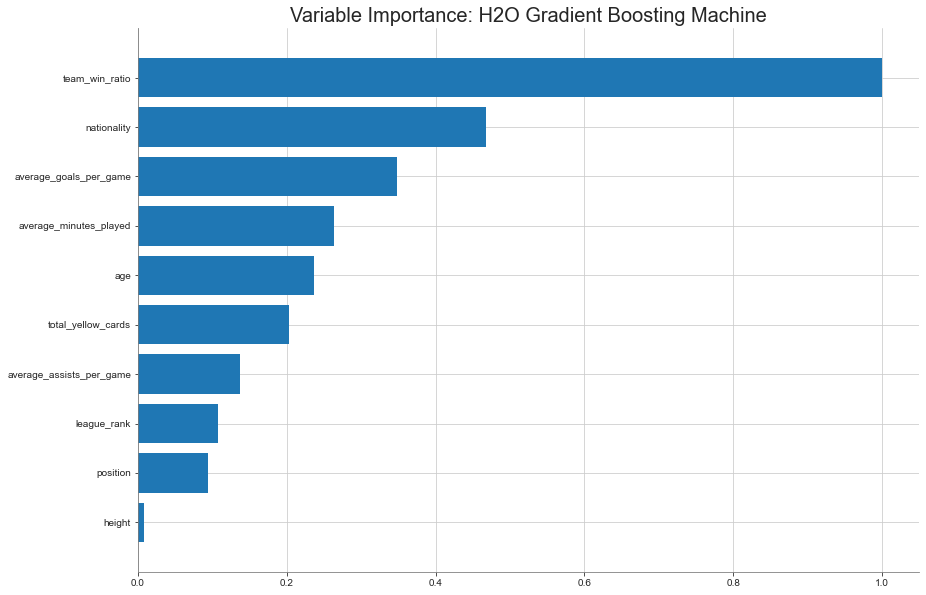

<Figure size 432x288 with 0 Axes>

In [39]:
# Variable importance (from default GBM — the winner)
gbm_default.varimp_plot()

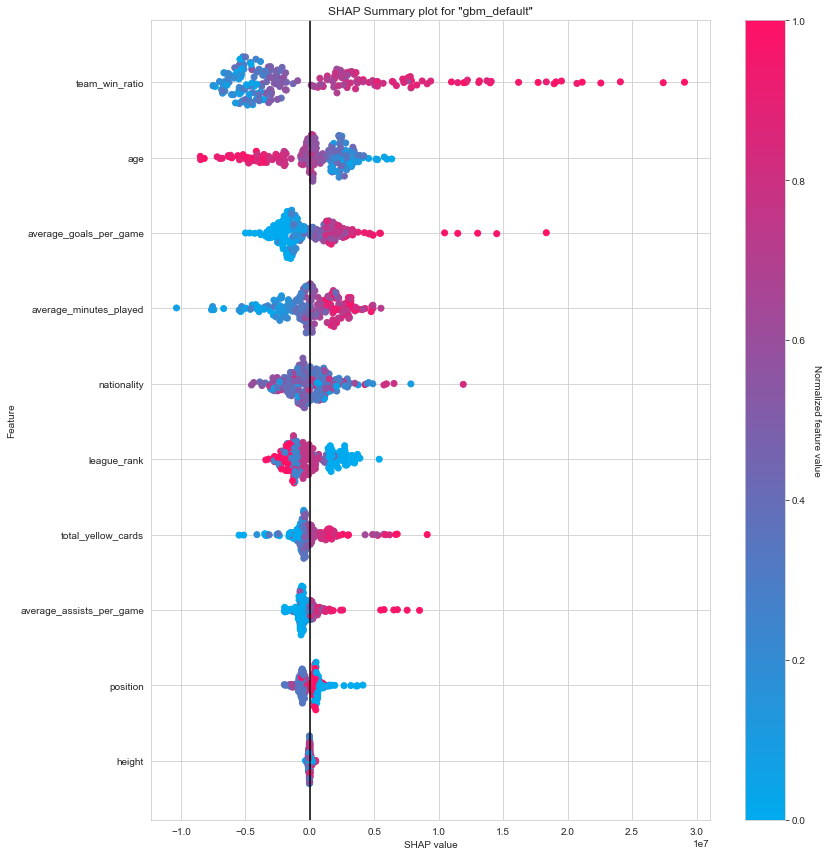

In [40]:
# SHAP summary across test set
gbm_default.shap_summary_plot(frame=test_h2o)

**Caveat on categorical features.**  For `nationality`, `position`, and
`league_rank`, the color scale (blue/red = "low/high value") is not meaningfully
ordered — these variables don't have an inherent numeric order.  Interpret
their SHAP magnitudes (spread along the x-axis) but not their color patterns.

---

## Step 9 — Individual SHAP explanations for three players

We pick three players spanning the accuracy spectrum:

- **Kylian Mbappé** — the model's easiest star to explain
- **Harry Kane** — an under-predicted superstar
- **Kalvin Phillips** — the model's biggest failure

We need to find these players in a frame that H2O can accept.  We push the
full dataset to H2O so we can look up any player.

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

### Kylian Mbappé
  Position: Attack, Age: 23, Actual value: €160,000,000

### Harry Kane
  Position: Attack, Age: 28, Actual value: €95,000,000

### Kalvin Phillips
  Position: Midfield, Age: 26, Actual value: €46,666,668


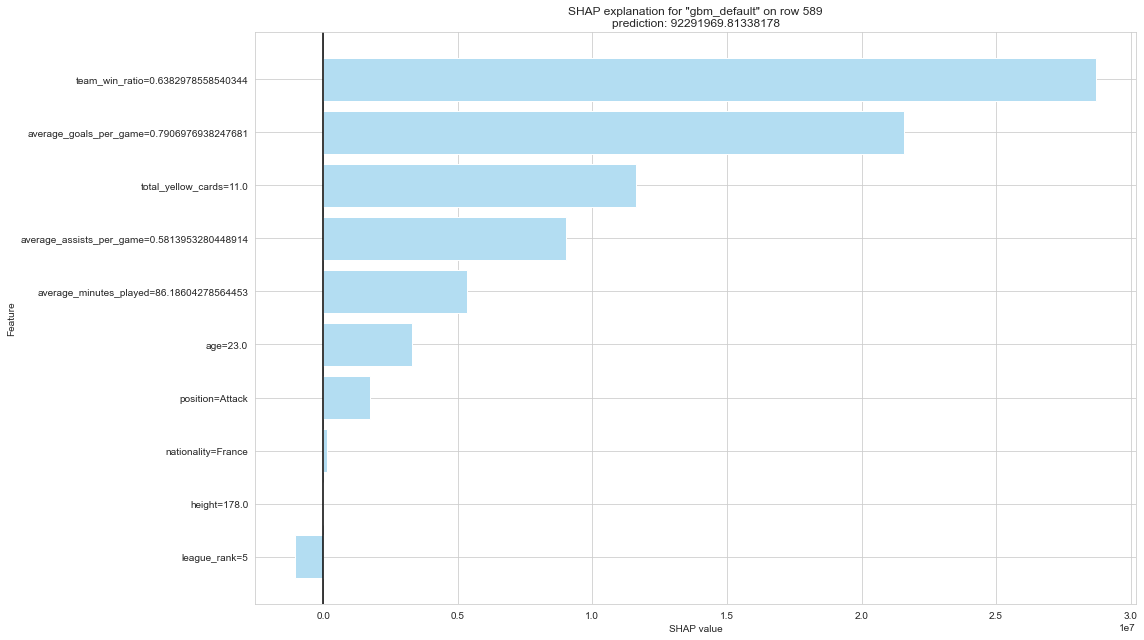

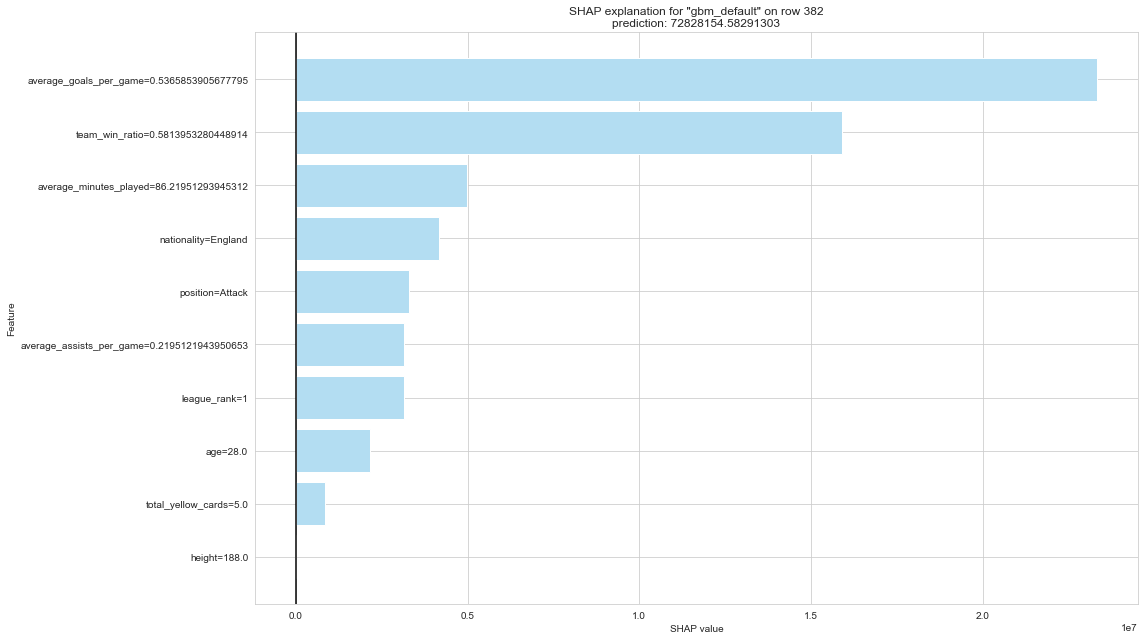

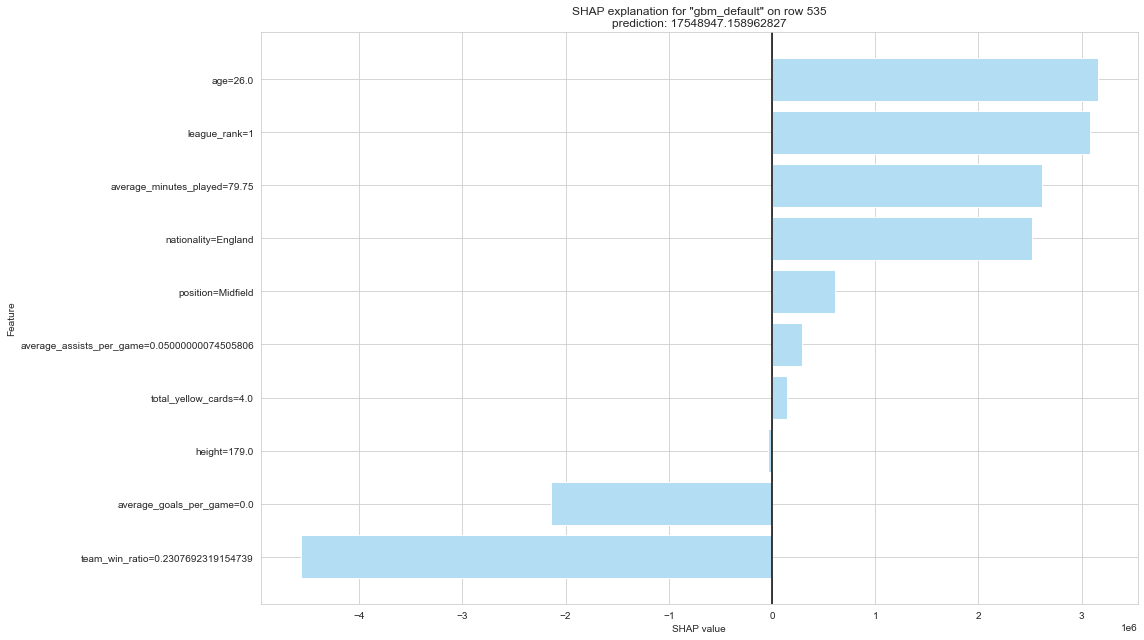

In [41]:
# Push the full data + convert categoricals for lookup
fifa_full = h2o.H2OFrame(df)
for c in ['position', 'nationality', 'league_rank']:
    fifa_full[c] = fifa_full[c].asfactor()

# Player row lookups (0-indexed in H2O)
players = {
    'Kylian Mbappé':    589,
    'Harry Kane':       382,
    'Kalvin Phillips':  535,
}

for name, row_idx in players.items():
    print(f"\n### {name}")
    row = df.iloc[row_idx]
    print(f"  Position: {row['position']}, Age: {row['age']}, "
          f"Actual value: €{row['average_market_value']:,.0f}")
    gbm_default.shap_explain_row_plot(frame=fifa_full, row_index=row_idx)

### Reading the three SHAP explanations

**Mbappé** — Every continuous predictor pushes positive.  Model predicts ~€95M
vs. actual €160M.  Even GBM can't reach the top of the distribution.

**Kane** — Predicted ~€75M vs. actual €95M.  Much closer than RF, because
GBM's sequential fitting can push predictions further from the mean.

**Phillips** — Predicted ~€9.5M vs. actual €46.7M.  SHAP shows the model
correctly reports that his team_win_ratio (0.23) and goals per game (0) both
push value *down*.  His €46.7M valuation comes from things this dataset can't
see: contract terms, transfer history, pre-2023 form.

---

## Wrap-up

**Five takeaways:**

1. RF beats OLS but not by much — the "10× better with ML" myth is a myth.
2. On skewed targets, OLS produces impossible negative predictions; tree
   methods don't.
3. GBM slightly outperforms RF — sequential residual-fitting captures a bit
   more signal.
4. **Tuning made both RF and GBM slightly worse** — losing training data to a
   validation split cost more than tuning gained.
5. SHAP explains individual predictions; when the target is influenced by
   factors outside your data (Phillips's contract, Kane's brand), no
   explanation covers the gap.

**The honest question:** which is more informative — that the model got
Mbappé right, or that it missed Kalvin Phillips by €37M?

## Cleaning up

In [42]:
# Shut down H2O when done
h2o.cluster().shutdown()

H2O session _sid_8c6f closed.


## Exercises for practice

1. Retrain the default GBM using `log(average_market_value)` as the target.
   Does R² improve?  Does Mbappé become better-predicted?
2. Drop `nationality` from the predictor list.  How much does test R² drop?
3. Tune the GBM's `max_depth` alongside `learn_rate` and `ntrees`.  Does the
   winner change?
4. Compute SHAP values for **your favorite player**.  Which features push their
   valuation up or down?  Are there surprises?
5. Fit a simple `LinearRegression` from `sklearn` on the same predictors.  Do
   you match the OLS results from statsmodels?  Any differences?  Why?